# Milestones 3–5 — Split, Models, and Training

**Project:** Intelligent Diabetic Retinopathy Detection and Progress Monitoring Using AI/ML

---

> ### ⚠️ Academic prototype — not a medical device
> Screening-support demonstration only. Not clinically validated. Not for diagnosis.

---

## How this notebook works

Training itself runs as a **script in a terminal**, not in a notebook cell. That's
deliberate: a 20-epoch run that dies because the kernel hiccupped at epoch 18 is a
lost evening, and notebooks are bad at long unattended jobs.

This notebook is the control panel around it:

| Section | What it does |
|---|---|
| 1–2 | Create and verify the train/val/test split |
| 3 | Build all three models and check they run — **before** you commit to an overnight job |
| 4 | The exact commands to launch training |
| 5 | Plot training curves (run this *during* training too — it reads from disk) |
| 6 | Compare the three architectures once they finish |

Sections 5 and 6 are re-runnable at any time. Leave the notebook open while
training runs in the terminal and re-run section 5 to watch progress.

## 1. Setup

In [1]:
import sys, json, subprocess
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
assert (PROJECT_ROOT / "src").is_dir(), f"src/ not found under {PROJECT_ROOT}"

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.config import class_names, get_path, load_config, load_experiment_config
from src.utils.seed import set_seed

cfg = load_config()
SEED = cfg["project"]["seed"]
set_seed(SEED)

DS          = cfg["dataset"]
ID_COL      = DS["id_col"]
LABEL_COL   = DS["label_col"]
CLASS_NAMES = class_names(cfg)

SPLITS_DIR      = get_path(cfg, "splits_dir")
EXPERIMENTS_DIR = get_path(cfg, "experiments_dir")
FIGURES_DIR     = get_path(cfg, "figures_dir")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENTS = ["resnet50", "efficientnet_b3", "densenet121"]

plt.rcParams["figure.dpi"] = 110
print("Project root :", PROJECT_ROOT)
print("Seed         :", SEED)
print("Experiments  :", EXPERIMENTS)

Project root : c:\Users\ishra\Downloads\dr_project\dr_project
Seed         : 42
Experiments  : ['resnet50', 'efficientnet_b3', 'densenet121']


## 2. The split

Run this in a terminal (it writes files, and it refuses to overwrite an existing split):

```powershell
python -m scripts.m3_split
```

Then run the cell below to inspect the result.

**Why stratification matters here:** Severe (class 3) is 5.3% of your data. A plain
random split could leave it badly under-represented in validation — and validation QWK
is what selects your model. The `drift_pp` column is the check: it's the largest gap,
in percentage points, between a split's share of a class and the overall share. Under
stratification it should be well under 1.

In [2]:
from src.data.split import split_distribution, verify_split, SPLIT_COL

all_splits_path = SPLITS_DIR / "all_splits.csv"

if not all_splits_path.is_file():
    print("No split found. Run this in a terminal first:")
    print("   python -m scripts.m3_split")
else:
    split_df = pd.read_csv(all_splits_path)

    problems = verify_split(split_df, ID_COL, LABEL_COL)
    if problems:
        print("SPLIT PROBLEMS - do not train on this:")
        for p in problems:
            print("  -", p)
    else:
        print("Split verified: no leakage, full coverage, all classes present in all splits.\n")

    sizes = split_df[SPLIT_COL].value_counts()
    total = len(split_df)
    for name in ("train", "val", "test"):
        print(f"  {name:<6} {sizes[name]:>5}  ({sizes[name]/total:.1%})")

    dist = split_distribution(split_df, LABEL_COL, DS["class_names"])
    display(dist)
    print(f"\nLargest class-share drift: {dist['drift_pp'].max():.2f} pp "
          f"({'good' if dist['drift_pp'].max() < 1 else 'CHECK stratify is true'})")

    meta_path = SPLITS_DIR / "split_meta.json"
    if meta_path.is_file():
        meta = json.loads(meta_path.read_text())
        print(f"\nFingerprint: {meta['fingerprint']}")
        print("Every training run records this. Two runs with different fingerprints")
        print("were trained on different data and must NOT be compared.")
        print("\nClass weights for weighted cross-entropy (from the TRAIN split only):")
        for name, w in zip(meta["class_names"], meta["class_weights_from_train"]):
            print(f"   {name:<18} {w:.4f}")

Split verified: no leakage, full coverage, all classes present in all splits.

  train   2562  (70.0%)
  val      550  (15.0%)
  test     550  (15.0%)


,label,class_name,train_n,train_pct,val_n,val_pct,test_n,test_pct,overall_pct,drift_pp
0,0,No DR,1263,49.30,271,49.27,271,49.27,49.29,0.02
1,1,Mild,258,10.07,56,10.18,56,10.18,10.10,0.08
2,2,Moderate,699,27.28,150,27.27,150,27.27,27.28,0.01
3,3,Severe,135,5.27,29,5.27,29,5.27,5.27,0.00
4,4,Proliferative DR,207,8.08,44,8.00,44,8.00,8.06,0.06



Largest class-share drift: 0.08 pp (good)

Fingerprint: 415bcc1c575a
Every training run records this. Two runs with different fingerprints
were trained on different data and must NOT be compared.

Class weights for weighted cross-entropy (from the TRAIN split only):
   No DR              0.2159
   Mild               1.0569
   Moderate           0.3901
   Severe             2.0198
   Proliferative DR   1.3173


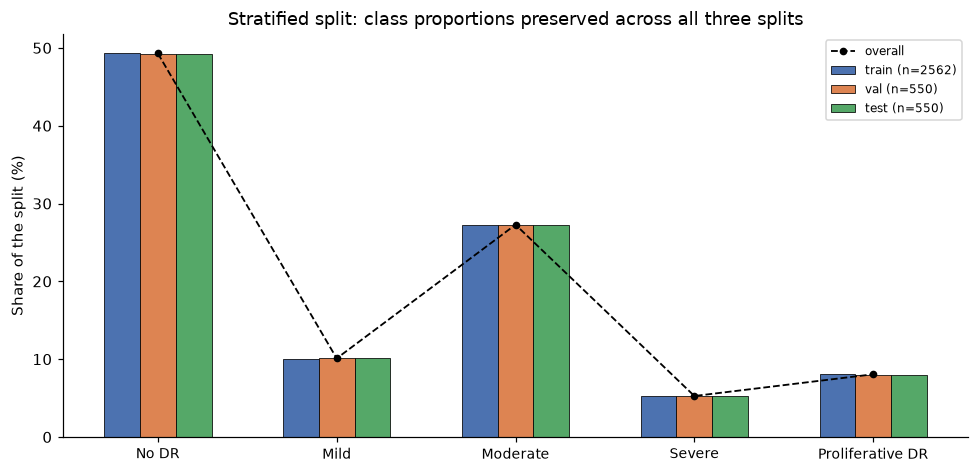

In [3]:
# Split distribution figure (also written by scripts/m3_split.py)
if all_splits_path.is_file():
    x = np.arange(len(CLASS_NAMES)); width = 0.2
    fig, ax = plt.subplots(figsize=(9, 4.4))
    for i, (name, colour) in enumerate([("train", "#4C72B0"), ("val", "#DD8452"),
                                        ("test", "#55A868")]):
        ax.bar(x + (i - 1) * width, dist[f"{name}_pct"], width,
               label=f"{name} (n={int(dist[f'{name}_n'].sum())})",
               color=colour, edgecolor="black", linewidth=0.5)
    ax.plot(x, dist["overall_pct"], "k--o", markersize=4, linewidth=1.2, label="overall", zorder=5)
    ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=9)
    ax.set_ylabel("Share of the split (%)")
    ax.set_title("Stratified split: class proportions preserved across all three splits")
    ax.legend(fontsize=8); ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout(); plt.show()

## 3. Pre-flight: do all three models actually build?

Before committing to an overnight job, check that each architecture constructs, downloads
its ImageNet weights, and produces the right output shape. This takes about a minute and
catches the boring failures (no internet for the weight download, a typo in a config)
while you're still awake.

First run downloads pretrained weights (~100–200 MB total) and caches them in
`~/.cache/huggingface`.

In [4]:
try:
    import torch
    from src.models.factory import build_model, check_forward, count_parameters, SUPPORTED_BACKBONES

    size = cfg["preprocessing"]["image_size"]
    rows = []

    for exp in EXPERIMENTS:
        exp_cfg = load_experiment_config(exp)
        backbone = exp_cfg["training"]["backbone"]
        print(f"building {backbone} ...", end=" ", flush=True)
        model = build_model(backbone, num_classes=DS["num_classes"], pretrained=True)
        shape = check_forward(model, size=size, num_classes=DS["num_classes"], device="cpu")
        total, trainable = count_parameters(model)
        rows.append({
            "experiment": exp,
            "backbone": backbone,
            "params_M": round(total / 1e6, 2),
            "output_shape": str(shape),
            "batch_size": exp_cfg["training"]["batch_size"],
            "grad_accum": exp_cfg["training"]["grad_accum_steps"],
            "effective_batch": exp_cfg["training"]["batch_size"] * exp_cfg["training"]["grad_accum_steps"],
            "lr": exp_cfg["training"]["lr"],
        })
        print("OK")
        del model

    display(pd.DataFrame(rows))
    print("\nAll three build and forward correctly. Note the parameter counts run")
    print("backwards to intuition: the newest design (EfficientNet-B3) is not the biggest,")
    print("and DenseNet121 is the smallest of all. That is the comparison's whole point.")

except ImportError as exc:
    print("PyTorch/timm not importable:", exc)
except Exception as exc:
    print(f"{type(exc).__name__}: {exc}")
    print("\nIf this is a download error, you are offline - pretrained weights are")
    print("fetched on first use. Connect and re-run.")

building resnet50 ... 

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

c:\Users\ishra\Downloads\dr_project\dr_project\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ishra\.cache\huggingface\hub\models--timm--resnet50.a1_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


OK
building efficientnet_b3 ... 

...

model.safetensors: downloading bytes:           |  0.00B            

c:\Users\ishra\Downloads\dr_project\dr_project\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ishra\.cache\huggingface\hub\models--timm--efficientnet_b3.ra2_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


OK
building densenet121 ... OK


,experiment,backbone,params_M,output_shape,batch_size,grad_accum,effective_batch,lr
0,resnet50,resnet50,23.52,"(2, 5)",8,2,16,0.0002
1,efficientnet_b3,efficientnet_b3,10.70,"(2, 5)",8,2,16,0.0003
2,densenet121,densenet121,6.96,"(2, 5)",6,3,18,0.0003



All three build and forward correctly. Note the parameter counts run
backwards to intuition: the newest design (EfficientNet-B3) is not the biggest,
and DenseNet121 is the smallest of all. That is the comparison's whole point.


In [5]:
# GPU check + a rough memory sanity test at your real batch size.
# If this OOMs, training certainly will - better to find out now.
try:
    import torch
    if not torch.cuda.is_available():
        print("No CUDA. Training will run on CPU and take many hours.")
    else:
        props = torch.cuda.get_device_properties(0)
        print(f"GPU: {props.name}  ({props.total_memory/1e9:.1f} GB)")
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()

        from src.models.factory import build_model
        size = cfg["preprocessing"]["image_size"]

        for exp in EXPERIMENTS:
            exp_cfg = load_experiment_config(exp)
            bs = exp_cfg["training"]["batch_size"]
            backbone = exp_cfg["training"]["backbone"]
            try:
                model = build_model(backbone, num_classes=5, pretrained=False).cuda().train()
                opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
                x = torch.randn(bs, 3, size, size, device="cuda")
                y = torch.randint(0, 5, (bs,), device="cuda")
                with torch.autocast("cuda", dtype=torch.float16):
                    loss = torch.nn.functional.cross_entropy(model(x), y)
                loss.backward(); opt.step()
                peak = torch.cuda.max_memory_allocated() / 1e9
                print(f"  {backbone:<18} batch {bs}: OK, peak {peak:.2f} GB")
            except RuntimeError as exc:
                if "out of memory" in str(exc).lower():
                    print(f"  {backbone:<18} batch {bs}: OUT OF MEMORY -> lower batch_size "
                          f"in configs/experiments/{exp}.yaml and raise grad_accum_steps")
                else:
                    raise
            finally:
                # Free everything before testing the next architecture, or the
                # second one OOMs on memory the first is still holding.
                for var in ("model", "opt", "x", "y", "loss"):
                    if var in locals():
                        del locals()[var]
                import gc; gc.collect()
                torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
except ImportError:
    print("PyTorch not installed.")

GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU  (6.4 GB)
  resnet50           batch 8: OK, peak 1.11 GB
  efficientnet_b3    batch 8: OK, peak 1.39 GB
  densenet121        batch 6: OK, peak 0.79 GB


## 4. Launch training — in a terminal

Copy these into a VS Code terminal. **Not** into a notebook cell: the data loader spawns
worker processes, and process pools started from Jupyter on Windows can hang.

### Step 1 — smoke test everything first (~5 min)

```powershell
powershell -ExecutionPolicy Bypass -File .\scripts\run_all.ps1
```

This runs 2 epochs on 64 images for each architecture, and only starts the real training
if all three pass. It also prints an estimated full-epoch time, so you'll know before bed
how long the night needs.

### Step 2 — the real runs

`run_all.ps1` continues into them automatically. To run one alone:

```powershell
python -m scripts.m4_train --experiment efficientnet_b3
```

### If something goes wrong

| Symptom | Fix |
|---|---|
| Exit code 2 / "CUDA out of memory" | Lower `batch_size` in that experiment's yaml, raise `grad_accum_steps` by the same factor. Same effective batch, same result, just slower. |
| Hangs before epoch 1 starts | Set `training.num_workers: 0` in `configs/config.yaml` |
| Run dies mid-way | `best.pt` is saved on every improvement — you still have the best model found so far |

Each run writes to `experiments/<run_name>/`:
`best.pt`, `history.csv`, `metrics_val.json`, `config_snapshot.yaml`, `train.log`,
`val_predictions.npz`.

## 5. Training curves

**Run this while training is still going.** It reads `history.csv` from disk, which is
rewritten after every epoch, so re-running this cell shows live progress.

What to look for:

- **val QWK rising then flattening** — normal, and the flattening is when early stopping fires
- **train loss falling while val loss rises** — overfitting; the checkpoint at best val QWK is still the one you want
- **val QWK stuck near 0** — something is wrong: check the class weights aren't extreme, or the LR isn't too high
- **spiky val curves** — expected, with only 550 validation images

In [6]:
def load_histories():
    """Read history.csv from every run folder that has one."""
    out = {}
    if not EXPERIMENTS_DIR.is_dir():
        return out
    for run_dir in sorted(EXPERIMENTS_DIR.iterdir()):
        hist = run_dir / "history.csv"
        if run_dir.is_dir() and hist.is_file() and not run_dir.name.startswith("smoke_"):
            try:
                out[run_dir.name] = pd.read_csv(hist)
            except pd.errors.EmptyDataError:
                pass          # being written to right now
    return out

histories = load_histories()

if not histories:
    print("No runs found yet in", EXPERIMENTS_DIR)
    print("Start training in a terminal, then re-run this cell.")
else:
    for name, h in histories.items():
        best_i = h["val_qwk"].idxmax()
        print(f"{name:<26} {len(h):>2} epochs | best val QWK {h.loc[best_i,'val_qwk']:.4f} "
              f"at epoch {int(h.loc[best_i,'epoch'])} | {h['epoch_seconds'].mean():.0f}s/epoch")

densenet121_weighted       13 epochs | best val QWK 0.8992 at epoch 8 | 46s/epoch
effnetb3_weighted           8 epochs | best val QWK 0.8938 at epoch 3 | 49s/epoch
resnet50_weighted          17 epochs | best val QWK 0.8949 at epoch 12 | 34s/epoch


Saved -> reports\figures\m5_training_curves.png


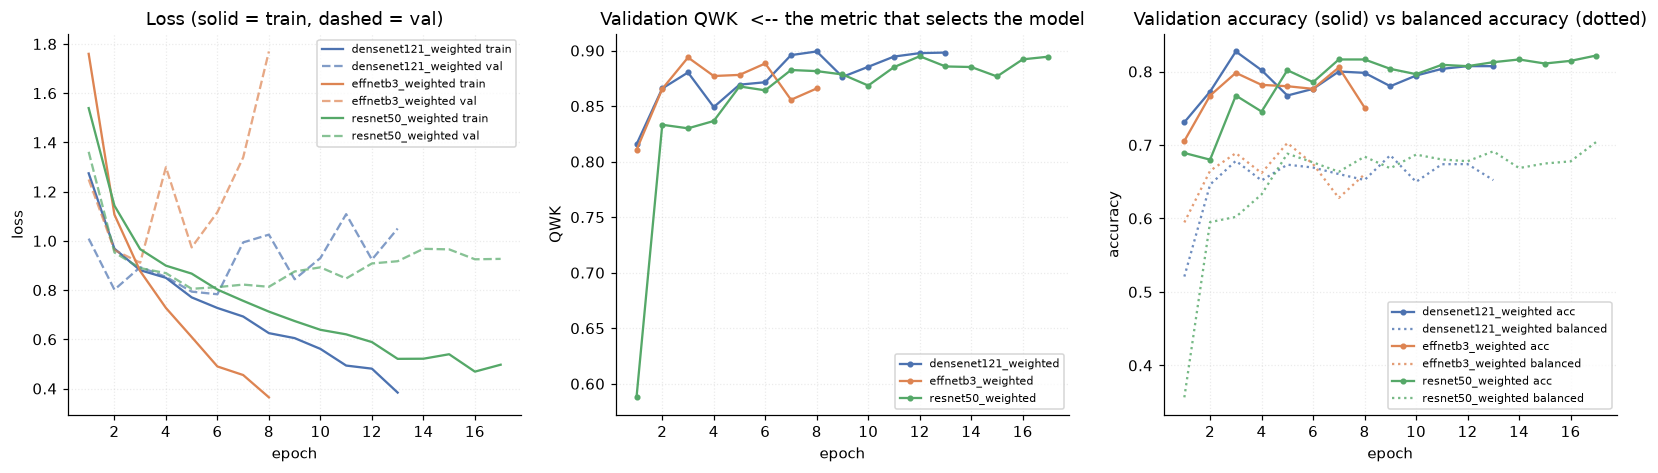


The gap between accuracy (solid) and balanced accuracy (dotted) in the third
panel shows how much the model is coasting on the 49% majority class.
A large gap means good overall accuracy hiding poor performance on rare classes.


In [7]:
if histories:
    COLOURS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

    for (name, h), colour in zip(histories.items(), COLOURS):
        axes[0].plot(h["epoch"], h["train_loss"], color=colour, label=f"{name} train")
        axes[0].plot(h["epoch"], h["val_loss"], color=colour, linestyle="--", alpha=0.7,
                     label=f"{name} val")
        axes[1].plot(h["epoch"], h["val_qwk"], color=colour, marker="o", markersize=3, label=name)
        axes[2].plot(h["epoch"], h["val_accuracy"], color=colour, marker="o", markersize=3,
                     label=f"{name} acc")
        axes[2].plot(h["epoch"], h["val_balanced_accuracy"], color=colour, linestyle=":",
                     alpha=0.8, label=f"{name} balanced")

    axes[0].set_title("Loss (solid = train, dashed = val)")
    axes[1].set_title("Validation QWK  <-- the metric that selects the model")
    axes[2].set_title("Validation accuracy (solid) vs balanced accuracy (dotted)")
    for ax, ylab in zip(axes, ["loss", "QWK", "accuracy"]):
        ax.set_xlabel("epoch"); ax.set_ylabel(ylab)
        ax.grid(alpha=0.25, linestyle=":"); ax.legend(fontsize=7)
        ax.spines[["top", "right"]].set_visible(False)

    fig.tight_layout()
    out = FIGURES_DIR / "m5_training_curves.png"
    fig.savefig(out, dpi=150)
    print(f"Saved -> {out.relative_to(PROJECT_ROOT)}")
    plt.show()

    print("\nThe gap between accuracy (solid) and balanced accuracy (dotted) in the third")
    print("panel shows how much the model is coasting on the 49% majority class.")
    print("A large gap means good overall accuracy hiding poor performance on rare classes.")

## 6. Compare the three architectures

Validation numbers only. **The test split is untouched** until Milestone 6, after all model
selection is finished — evaluating on test and then tuning would bias everything you report.

,run,backbone,val_QWK,val_acc,val_bal_acc,val_F1_macro,val_AUC_macro,best_epoch,epochs_run,minutes,eff_batch,fingerprint
0,densenet121_weighted,densenet121,0.8992,0.7982,0.6524,0.6450,0.9323,8,13,10.07,18,415bcc1c575a
1,resnet50_weighted,resnet50,0.8949,0.8073,0.6779,0.6698,0.9390,12,17,9.68,16,415bcc1c575a
2,effnetb3_weighted,efficientnet_b3,0.8938,0.7982,0.6889,0.6654,0.9420,3,8,6.55,16,415bcc1c575a



All runs share split fingerprint 415bcc1c575a - the comparison is valid.

Best by validation QWK: densenet121 (0.8992)
Use this model for Grad-CAM (Milestone 7) and the Streamlit app (Milestone 10).


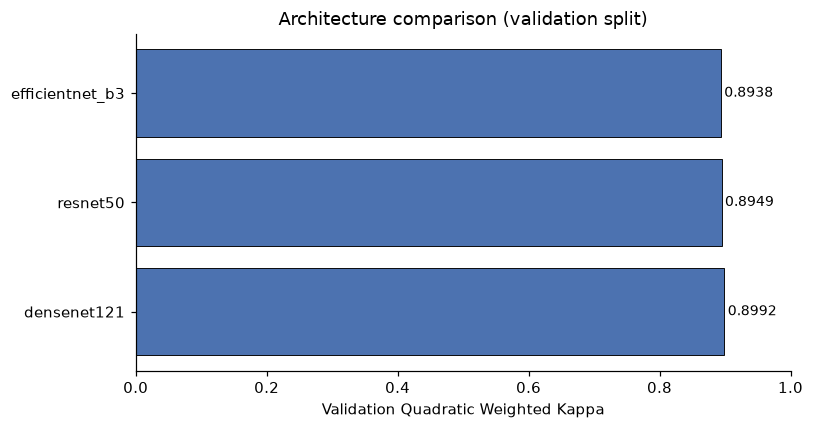

In [8]:
rows = []
for run_dir in sorted(EXPERIMENTS_DIR.iterdir()) if EXPERIMENTS_DIR.is_dir() else []:
    mpath = run_dir / "metrics_val.json"
    if not mpath.is_file() or run_dir.name.startswith("smoke_"):
        continue
    data = json.loads(mpath.read_text())
    s, m = data["summary"], data["val_metrics"]
    rows.append({
        "run": s["run_name"],
        "backbone": s["backbone"],
        "val_QWK": m.get("qwk"),
        "val_acc": m.get("accuracy"),
        "val_bal_acc": m.get("balanced_accuracy"),
        "val_F1_macro": m.get("f1_macro"),
        "val_AUC_macro": m.get("auc_macro"),
        "best_epoch": s["best_epoch"],
        "epochs_run": s["epochs_run"],
        "minutes": s["total_minutes"],
        "eff_batch": s["effective_batch"],
        "fingerprint": s["split_fingerprint"],
    })

if not rows:
    print("No completed runs yet. Finish training, then re-run this cell.")
else:
    comp = pd.DataFrame(rows).sort_values("val_QWK", ascending=False).reset_index(drop=True)
    display(comp)

    # Every run MUST share a split fingerprint, or the comparison is invalid.
    prints = comp["fingerprint"].unique()
    if len(prints) > 1:
        print("\nWARNING: runs used DIFFERENT splits", prints)
        print("They are not comparable. Re-train on one split.")
    else:
        print(f"\nAll runs share split fingerprint {prints[0]} - the comparison is valid.")

    best = comp.iloc[0]
    print(f"\nBest by validation QWK: {best['backbone']} ({best['val_QWK']:.4f})")
    print("Use this model for Grad-CAM (Milestone 7) and the Streamlit app (Milestone 10).")

    comp.to_csv(get_path(cfg, "reports_dir") / "m5_validation_comparison.csv", index=False)

    fig, ax = plt.subplots(figsize=(7.5, 4))
    ax.barh(comp["backbone"], comp["val_QWK"], color="#4C72B0", edgecolor="black", linewidth=0.6)
    for i, v in enumerate(comp["val_QWK"]):
        ax.text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=9)
    ax.set_xlabel("Validation Quadratic Weighted Kappa")
    ax.set_title("Architecture comparison (validation split)")
    ax.set_xlim(0, min(1.0, comp["val_QWK"].max() * 1.2))
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "m5_architecture_comparison.png", dpi=150)
    plt.show()

---

## Done with Milestones 3–5

Commit:

```powershell
git add .
git commit -m "Milestones 3-5: split, three architectures trained"
git tag m5
```

**Next: Milestone 6** — evaluate the best model on the held-out test split (once), and
produce the confusion matrices, per-class table and ROC curves for your report.

Tell your mentor the validation comparison table from section 6 and roughly how long each
run took.